In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm 

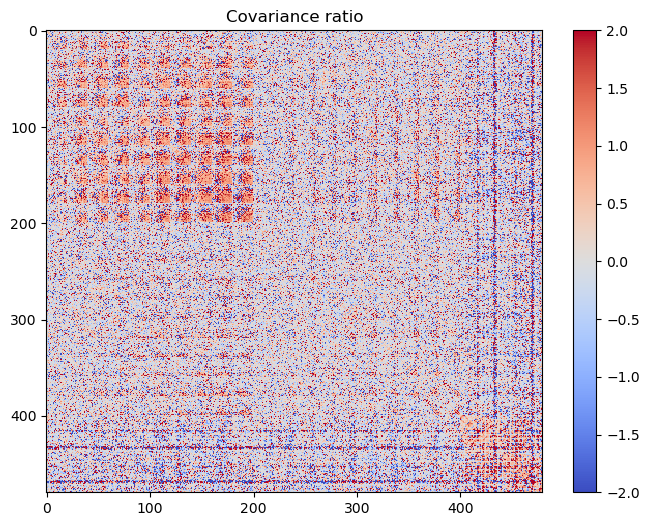

In [20]:
full_cov_unweighted = fits.open('../data/covariance/cov_xip_xim_map3.fits')
full_cov_weighted = fits.open('../data/covariance/cov_xip_xim_map3_weighted.fits')

fcw_scratch = np.load('/Users/gchgomes/3pcf_integrator/data/xip_xim_map3_dv_and_cov/24Jul_xip_xim_map3_COV.npy')
fcuw_old_file = fits.open('/Users/gchgomes/3pcf_integrator_backup/cov_xip_xim_map3.fits')

#print(full_cov_unweighted[1].header)
#print(full_cov_weighted[1].header)
#print(fcuw_old_file[1].header)

no_weights = full_cov_unweighted[1].data
weights = full_cov_weighted[1].data

fcuw_old = fcuw_old_file[1].data

#print(weights/fcuw_old)

ratt = weights/fcuw_old

plt.figure(figsize=(8, 6))
plt.imshow(ratt, cmap='coolwarm', interpolation='none', aspect='auto', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Covariance ratio')
plt.show()

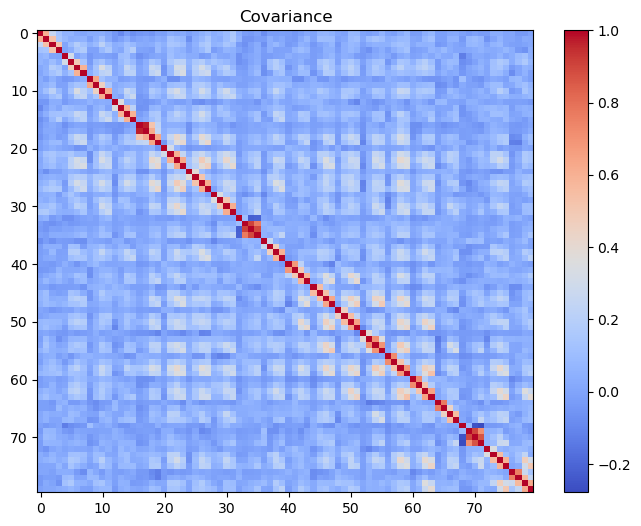

In [43]:
full_cov_unweighted = fits.open('../data/covariance/cov_xip_xim_map3.fits')
full_cov_weighted = fits.open('../data/covariance/cov_xip_xim_map3_weighted.fits')

fcw_scratch = np.load('/Users/gchgomes/3pcf_integrator/data/xip_xim_map3_dv_and_cov/24Jul_xip_xim_map3_COV.npy')
fcuw_old_file = fits.open('/Users/gchgomes/3pcf_integrator_backup/cov_xip_xim_map3.fits')

#print(full_cov_unweighted[1].header)
#print(full_cov_weighted[1].header)
#print(fcuw_old_file[1].header)

no_weights = full_cov_unweighted[1].data
weights = full_cov_weighted[1].data

fcuw_old = fcuw_old_file[1].data
std_dev = np.sqrt(np.diag(weights))
corr = weights / np.outer(std_dev, std_dev)
corrm3 = corr[400:,:][:,400:]

plt.figure(figsize=(8, 6))
plt.imshow(corrm3, cmap='coolwarm', interpolation='none', aspect='auto')
plt.colorbar()
plt.title('Covariance')
plt.show()

In [27]:
std_dev_w = np.sqrt(np.diag(weights))
correl_w = weights / np.outer(std_dev_w, std_dev_w)

std_dev_u = np.sqrt(np.diag(fcuw_old))
correl_u = fcuw_old / np.outer(std_dev_u, std_dev_u)

ratt_cor = correl_w/correl_u
ratt_map3 = ratt_cor[400:,:][:,400:]

print(std_dev_w/std_dev_u)
ratio_std = std_dev_w/std_dev_u

[0.66572624 0.6498573  0.75886319 0.62139839 0.6761165  0.73154212
 0.66408241 0.61112897 0.7385483  0.86452034 0.70640756 0.79086175
 0.74778213 0.77064813 0.77190071 0.75159619 0.80684029 0.77433244
 0.79978224 0.74756644 0.60888518 0.66990671 0.74727124 0.66273105
 0.81515882 0.69405289 0.74139721 0.62526722 0.71046112 0.71528377
 0.70597379 0.69744477 0.73866476 0.84542367 0.90845179 0.81000122
 0.7619361  0.89144528 0.70212088 0.87825044 0.68562175 0.72819501
 0.66998727 0.64912983 0.7116675  0.62906384 0.707659   0.77557593
 0.75219096 0.75067007 0.74412504 0.73791605 0.72922748 0.83294185
 0.76200959 0.76071411 0.81946533 0.76934545 0.82712533 0.87224349
 0.7078297  0.68642153 0.64598751 0.71640396 0.7830124  0.67525406
 0.61401684 0.66516911 0.67967463 0.70775813 0.69288473 0.88369005
 0.89384412 0.80650717 0.80795928 0.82130857 0.82142094 0.83960813
 0.8619148  0.94748841 0.68094058 0.66618494 0.72378253 0.77543562
 0.66653371 0.73531822 0.8195306  0.80038088 0.756972   0.7354

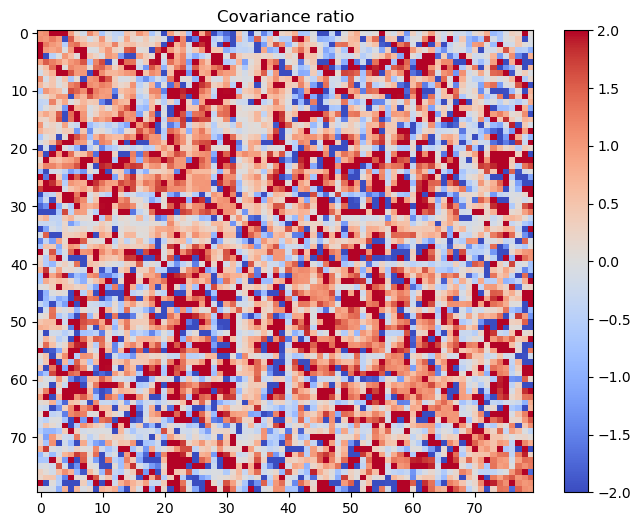

In [28]:
plt.figure(figsize=(8, 6))
plt.imshow(ratt_map3, cmap='coolwarm', interpolation='none', aspect='auto', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Covariance ratio')
plt.show()

1.1061729910833924


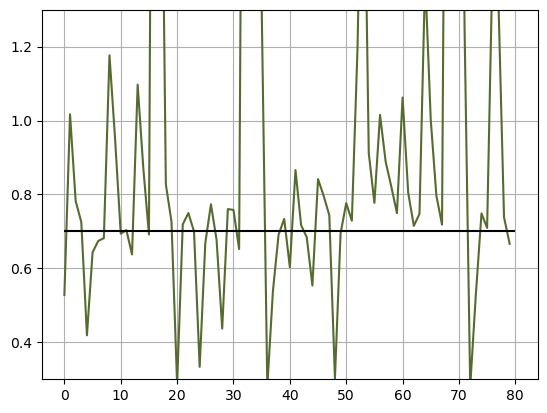

In [39]:
print(np.average(ratio_std[400:]))
plt.plot(np.arange(80),ratio_std[400:], color='darkolivegreen')
plt.hlines(0.7,xmin=0,xmax=80, color='k')
plt.ylim(0.3,1.3)
plt.grid()
plt.show()

In [ ]:
full_cov_unweighted = fits.open('../data/covariance/cov_xip_xim_map3.fits')
full_cov_unweighted.info()
fcuw = full_cov_unweighted[1].data

std_dev = np.sqrt(np.diag(fcuw))
corr = fcuw / np.outer(std_dev, std_dev)

plt.figure(figsize=(8, 6))
plt.imshow(fcuw, cmap='coolwarm', interpolation='none', aspect='auto', norm=LogNorm())
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

In [ ]:
full_cov_weighted = fits.open('../data/covariance/cov_xip_xim_map3_weighted.fits')
full_cov_weighted.info()
fcw = full_cov_weighted[1].data

std_dev = np.sqrt(np.diag(fcw))
corr = fcw / np.outer(std_dev, std_dev)

plt.figure(figsize=(8, 6))
plt.imshow(fcw, cmap='coolwarm', interpolation='none', aspect='auto', norm=LogNorm())
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

In [ ]:
ratt = fcw/fcuw

plt.figure(figsize=(8, 6))
plt.imshow(ratt, cmap='coolwarm', interpolation='none', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

In [ ]:
diff = fcuw - fcw
print(diff)